# Construcción de zonas sociodemográficas mediante AGEB

Esta notebook obtiene los AGEB urbanos y rurales correspondientes a los municipios de interés del Área Metropolitana de Guadalajara.

A partir de información censal y del DENUE, se calculan atributos demográficos y espaciales para cada AGEB, incluyendo población, establecimientos, empleo estimado, densidades y distancia al centro de Guadalajara.

In [20]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import mxcensus
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

### Lectura de las cabeceras municipales

Cargamos las localidades para identificar la cabecera municipal de Guadalajara. Sus coordenadas las usaremos como punto de referencia para calcular la distancia de cada AGEB al centro de la ciudad.

In [ ]:
ruta_datos = Path("/Users/.../asignacion_atributos")
localidades = pd.read_csv(ruta_datos / "datos_asignacion_atributos/cabeceras_gdl.csv", encoding="latin1", skiprows=3, dtype=str)
localidades.head()

,CVEGEO,Estatus,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_LOC,NOM_LOC,AMBITO,LATITUD,LONGITUD,LAT_DECIMAL,LON_DECIMAL,ALTITUD,CVE_CARTA,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
0,140010001,NaN,14,Jalisco,Jal.,001,Acatic,0001,Acatic,U,"20°46´46.000""N","102°54´19.000""W",20.779444,-102.905278,1690,F13D57,13033,6336,6697,3675
1,140020001,NaN,14,Jalisco,Jal.,002,Acatlán de Juárez,0001,Acatlán de Juárez,U,"20°25´17.000""N","103°35´14.000""W",20.421388,-103.587222,1381,F13D75,11110,5468,5642,3067
2,140030001,NaN,14,Jalisco,Jal.,003,Ahualulco de Mercado,0001,Ahualulco de Mercado,U,"20°42´02.000""N","103°58´30.000""W",20.700556,-103.974999,1321,F13D64,17000,8473,8527,4732
3,140040001,NaN,14,Jalisco,Jal.,004,Amacueca,0001,Amacueca,U,"20°00´38.000""N","103°35´46.000""W",20.010556,-103.596111,1409,F13D85,3025,1463,1562,871
4,140050001,NaN,14,Jalisco,Jal.,005,Amatitán,0001,Amatitán,U,"20°50´06.000""N","103°43´48.000""W",20.835,-103.729999,1248,F13D54,12180,5986,6194,3108


## Obtención de los AGEB

Con `mxcensus` cargamos la información de los censos y las geometrías de los AGEB del estado de Jalisco.

La función nos devuelve:

- los polígonos de los AGEB
- las localidades asociadas a la información censal

In [4]:
agebs_jalisco, localidades_agebs_jalisco = mxcensus.load_mg_census(state=14)

print(f"AGEB disponibles en Jalisco: {len(agebs_jalisco):,}")
print(f"Localidades disponibles en Jalisco: {len(localidades_agebs_jalisco):,}")

AGEB disponibles en Jalisco: 5,873
Localidades disponibles en Jalisco: 24,038


### Selección del área de estudio

A partir del conjunto estatal, seleccionamos los AGEB pertenecientes a los municipios que conforman el área de estudio.

In [5]:
municipios_objetivo = {
    39: "Guadalajara",
    120: "Zapopan",
    98: "San Pedro Tlaquepaque",
    97: "Tlajomulco de Zúñiga",
    101: "Tonalá",
    70: "El Salto",
    51: "Juanacatlán",
    44: "Ixtlahuacán de los Membrillos",
    124: "Zapotlanejo",
    83: "Tala"
}

agebs_jalisco = agebs_jalisco.reset_index()
agebs_zmg = agebs_jalisco.loc[(agebs_jalisco["ENTIDAD"] == 14) & (agebs_jalisco["MUN"].isin(municipios_objetivo))].copy()
agebs_zmg["NOM_MUN"] = agebs_zmg["MUN"].map(municipios_objetivo)

print(f"AGEB seleccionados: {len(agebs_zmg):,}")
print(agebs_zmg["NOM_MUN"].value_counts().to_string())

AGEB seleccionados: 2,203
NOM_MUN
Zapopan                          546
Guadalajara                      443
Tlajomulco de Zúñiga             390
San Pedro Tlaquepaque            238
Tonalá                           233
El Salto                         133
Tala                             107
Zapotlanejo                       54
Ixtlahuacán de los Membrillos     39
Juanacatlán                       20


## Incorporación de información económica

Para complementar la información de los AGEB, cargamos el DENUE correspondiente al estado de Jalisco.

Esta fuente nos ayudará a estimar dentro de cada AGEB:

- el número total de establecimientos
- el número estimado de personas empleadas

In [6]:
denue_jalisco = mxcensus.load_denue(state=14)
print(f"Establecimientos disponibles en el DENUE de Jalisco: {len(denue_jalisco):,}")

Establecimientos disponibles en el DENUE de Jalisco: 401,813


### Estimación del personal

El DENUE reporta el personal ocupado mediante rangos, no como una cantidad exacta. Para obtener una variable numérica, asignamos a cada rango una estimación del número esperado de empleados.

Posteriormente, filtramos los establecimientos pertenecientes a los municipios del área de estudio y agregamos esta estimación como una nueva columna.

In [7]:
mapeo_empleos_esperados = {
    "0 a 5 personas": 3,
    "6 a 10 personas": 7.44092985,
    "11 a 30 personas": 16.90612308,
    "31 a 50 personas": 38.74564318,
    "51 a 100 personas": 69.56199949,
    "101 a 250 personas": 152.1643003,
    "251 y más personas": 737.0838422
}

codigos_municipios = [f"{codigo:03d}" for codigo in municipios_objetivo]
denue_zmg = denue_jalisco.loc[(denue_jalisco["cve_ent"] == "14") & (denue_jalisco["cve_mun"].isin(codigos_municipios))].copy()
denue_zmg["num_empleos_esperados"] = denue_zmg["per_ocu"].map(mapeo_empleos_esperados)

print(f"Establecimientos seleccionados: {len(denue_zmg):,}")
print(f"Establecimientos sin estimación de empleados: {denue_zmg['num_empleos_esperados'].isna().sum():,}")

Establecimientos seleccionados: 235,458
Establecimientos sin estimación de empleados: 0


### Agregación de establecimientos y empleos por AGEB

Para asignar la información económica a cada AGEB, reproyectamos los establecimientos al mismo sistema de coordenadas de los polígonos censales y realizamos una unión espacial. Cada establecimiento se asigna al AGEB dentro del cual se encuentra. Después, la información se agrupa por `CVEGEO` para calcular:

- el número total de establecimientos
- la suma estimada de empleados

Los AGEB sin establecimientos reciben 0 en ambas variables.

In [8]:
denue_zmg_metrico = denue_zmg.to_crs(agebs_zmg.crs)
denue_agebs = gpd.sjoin(denue_zmg_metrico[["id", "num_empleos_esperados", "geometry"]], agebs_zmg[["CVEGEO", "geometry"]], how="inner", predicate="within")
atributos_denue_ageb = denue_agebs.groupby("CVEGEO").agg(establecimientos_totales=("id", "count"), empleados_totales=("num_empleos_esperados", "sum")).reset_index()

agebs_zmg = agebs_zmg.merge(atributos_denue_ageb, on="CVEGEO", how="left")
agebs_zmg["establecimientos_totales"] = agebs_zmg["establecimientos_totales"].fillna(0).astype("int64")
agebs_zmg["empleados_totales"] = agebs_zmg["empleados_totales"].fillna(0.0)

print(f"Establecimientos asignados a un AGEB: {len(denue_agebs):,}")
print(f"AGEB con al menos un establecimiento: {(agebs_zmg['establecimientos_totales'] > 0).sum():,}")

Establecimientos asignados a un AGEB: 235,458
AGEB con al menos un establecimiento: 2,024


## Cálculo de indicadores territoriales

A partir de la geometría de cada AGEB calculamos su superficie en metros cuadrados y kilómetros cuadrados. Con estas superficies construimos tres indicadores de densidad territorial:

- población por kilómetro cuadrado
- establecimientos por kilómetro cuadrado
- empleos estimados por kilómetro cuadrado

Como las geometrías se encuentran en un sistema de coordenadas proyectado, sus áreas pueden calcularse directamente en metros cuadrados.

In [10]:
agebs_zmg["area_m2"] = agebs_zmg.geometry.area
agebs_zmg["area_km2"] = agebs_zmg["area_m2"] / 1_000_000

agebs_zmg["densidad_poblacion_km2"] = agebs_zmg["POBTOT"] / agebs_zmg["area_km2"]
agebs_zmg["densidad_establecimientos_km2"] = agebs_zmg["establecimientos_totales"] / agebs_zmg["area_km2"]
agebs_zmg["densidad_empleo_km2"] = agebs_zmg["empleados_totales"] / agebs_zmg["area_km2"]

## Distancia al centro de Guadalajara

Para representar la localización relativa de cada AGEB dentro del área de estudio, utilizamos como referencia la cabecera municipal de Guadalajara.

Primero identificamos sus coordenadas del `.csv` de localidades y las transformamos al mismo sistema de coordenadas de los AGEB. Después calculamos la distancia euclidiana entre el centroide de cada polígono y el punto de referencia.

**Nota:** La distancia final se expresa en kilómetros.

In [14]:
cabecera_guadalajara = localidades.loc[(localidades["CVE_ENT"] == "14") & (localidades["CVE_MUN"] == "039") & (localidades["CVE_LOC"] == "0001")].copy()
centro_guadalajara = gpd.GeoDataFrame(cabecera_guadalajara, geometry=gpd.points_from_xy(cabecera_guadalajara["LON_DECIMAL"].astype(float), cabecera_guadalajara["LAT_DECIMAL"].astype(float)), crs="EPSG:4326").to_crs(agebs_zmg.crs)
punto_centro_guadalajara = centro_guadalajara.geometry.iloc[0]

agebs_zmg["centroide"] = agebs_zmg.geometry.centroid
agebs_zmg["distancia_centro_gdl_km"] = agebs_zmg["centroide"].distance(punto_centro_guadalajara) / 1000

## Capa final

Estandarizamos los nombres de las variables y conservamos únicamente los atributos necesarios:

- identificadores del censo
- municipio y tipo de AGEB
- población total
- superficie
- establecimientos y empleos estimados
- densidades territoriales
- distancia al centro de Guadalajara
- geometría

**Nota:** las categorías `AGEB_URBAN` y `AGEB_RURAL` se cambian a `urbano` y `rural`.

In [16]:
agebs_zmg = agebs_zmg.rename(columns={"CVEGEO": "clave_ageb", "ENTIDAD": "clave_entidad", "MUN": "clave_municipio", "LOC": "clave_localidad", "AGEB": "ageb", "NOM_MUN": "nombre_municipio", "ADMIN_TYPE": "tipo_ageb", "POBTOT": "poblacion_total"})
columnas_finales = ["clave_ageb", "clave_entidad", "clave_municipio", "clave_localidad", "ageb", "nombre_municipio", "tipo_ageb", "poblacion_total", "area_m2", "area_km2", "establecimientos_totales", "empleados_totales", "densidad_poblacion_km2", "densidad_establecimientos_km2", "densidad_empleo_km2", "distancia_centro_gdl_km", "geometry"]

zonas_agebs = agebs_zmg[columnas_finales].copy()
zonas_agebs["tipo_ageb"] = zonas_agebs["tipo_ageb"].replace({"AGEB_URBAN": "urbano", "AGEB_RURAL": "rural"})

zonas_agebs.head()

,clave_ageb,clave_entidad,clave_municipio,clave_localidad,ageb,nombre_municipio,tipo_ageb,poblacion_total,area_m2,area_km2,establecimientos_totales,empleados_totales,densidad_poblacion_km2,densidad_establecimientos_km2,densidad_empleo_km2,distancia_centro_gdl_km,geometry
0,140392874,14,39,0,2874,Guadalajara,rural,8,8.486753e+06,8.486753,2,24.347053,0.942646,0.235661,2.868830,7.537020,"MULTIPOLYGON (((2363989.299 972099.751, 236414..."
1,1403900010026,14,39,1,0026,Guadalajara,urbano,1433,4.719139e+05,0.471914,67,1529.814941,3036.571136,141.975064,3241.724978,5.583186,"MULTIPOLYGON (((2356822.264 967782.506, 235682..."
2,1403900010030,14,39,1,0030,Guadalajara,urbano,3440,1.612152e+06,1.612152,331,14409.866313,2133.793827,205.315627,8938.280170,4.470820,"MULTIPOLYGON (((2357908.827 968014.844, 235790..."
3,140390001005A,14,39,1,005A,Guadalajara,urbano,1538,1.953332e+05,0.195333,93,1548.060105,7873.724252,476.109464,7925.226524,4.270276,"MULTIPOLYGON (((2358490.603 967128.043, 235848..."
4,1403900010064,14,39,1,0064,Guadalajara,urbano,2647,3.432409e+05,0.343241,89,527.716337,7711.784729,259.293102,1537.451754,3.822108,"MULTIPOLYGON (((2359338.344 967381.133, 235933..."


## Visualización

Los paneles muestran:

1. la distribución de AGEB urbanos y rurales
2. la densidad de población
3. la densidad estimada de empleo

En los mapas de densidad, la escala de color se limita al percentil 95 para mejorar contraste.

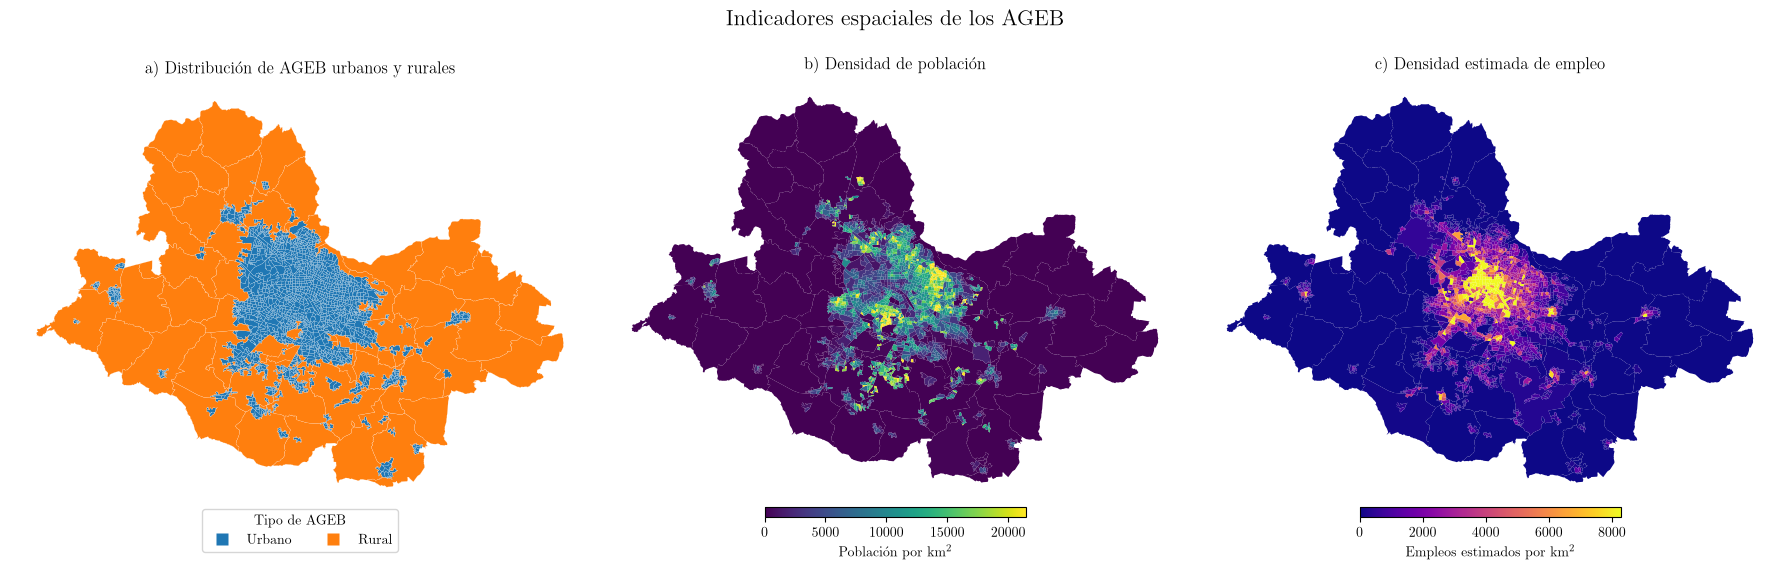

In [84]:
limite_densidad_poblacion = zonas_agebs["densidad_poblacion_km2"].quantile(0.95)
limite_densidad_empleo = zonas_agebs["densidad_empleo_km2"].quantile(0.95)

colores_tipo_ageb = {"urbano": "tab:blue", "rural": "tab:orange"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for tipo_ageb, color in colores_tipo_ageb.items():
    zonas_agebs.loc[zonas_agebs["tipo_ageb"] == tipo_ageb].plot(ax=axes[0], color=color, edgecolor="white", linewidth=0.1)

leyenda_tipo_ageb = [Line2D([0], [0], marker="s", color="none", markerfacecolor=color, markeredgecolor="none", markersize=9, label=tipo.capitalize()) for tipo, color in colores_tipo_ageb.items()]
axes[0].legend(handles=leyenda_tipo_ageb, title="Tipo de AGEB", loc="upper center", bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=True)
axes[0].set_title(r"$\mathrm{a)}$ Distribución de AGEB urbanos y rurales")
axes[0].set_axis_off()

zonas_agebs.plot(ax=axes[1], column="densidad_poblacion_km2", cmap="viridis", vmin=0, vmax=limite_densidad_poblacion, legend=True, edgecolor="none", legend_kwds={"label": r"Población por km$^2$", "shrink": 0.45, "aspect": 25, "orientation": "horizontal", "pad": 0.01})
axes[1].set_title(r"$\mathrm{b)}$ Densidad de población")
axes[1].set_axis_off()

zonas_agebs.plot(ax=axes[2], column="densidad_empleo_km2", cmap="plasma", vmin=0, vmax=limite_densidad_empleo, legend=True, edgecolor="none", legend_kwds={"label": r"Empleos estimados por km$^2$", "shrink": 0.45, "aspect": 25, "orientation": "horizontal", "pad": 0.01})
axes[2].set_title(r"$\mathrm{c)}$ Densidad estimada de empleo")
axes[2].set_axis_off()

fig.suptitle("Indicadores espaciales de los AGEB", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
pos = axes[0].get_position()
axes[0].set_position([pos.x0, pos.y0 + 0.06, pos.width, pos.height])
plt.show()

Como complemento a los mapas, graficamos la relación entre la distancia al centro de Guadalajara y la densidad estimada de empleo.

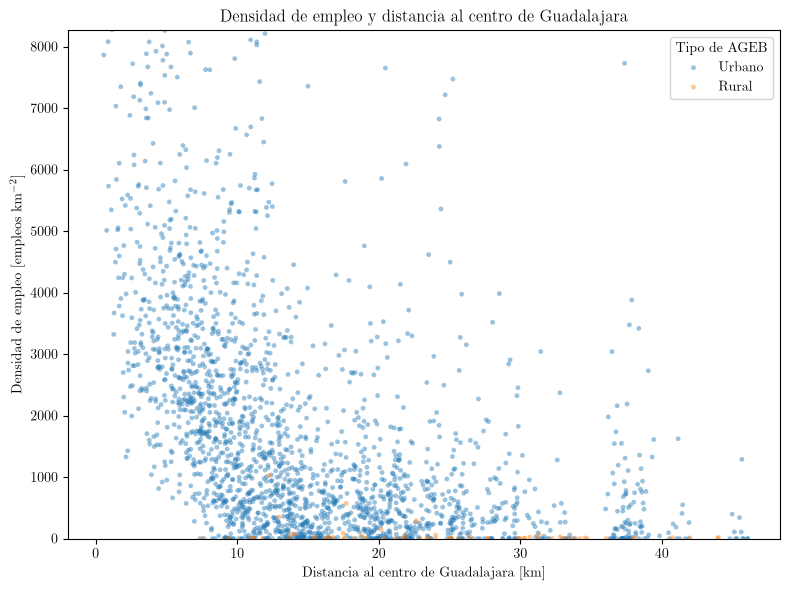

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for tipo_ageb, color in colores_tipo_ageb.items():
    datos_tipo = zonas_agebs.loc[zonas_agebs["tipo_ageb"] == tipo_ageb]
    ax.scatter(datos_tipo["distancia_centro_gdl_km"], datos_tipo["densidad_empleo_km2"], s=12, alpha=0.45, color=color, edgecolors="none", label=tipo_ageb.capitalize())

ax.set_title(r"Densidad de empleo y distancia al centro de Guadalajara")
ax.set_xlabel(r"Distancia al centro de Guadalajara [km]")
ax.set_ylabel(r"Densidad de empleo [empleos km$^{-2}$]")
ax.set_ylim(0, limite_densidad_empleo)
ax.grid(False)
ax.legend(title="Tipo de AGEB")

plt.tight_layout()
plt.show()